In [3]:
import os   ##最终
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0,4]  # 修改为 [2]
d22 = [0,4]  # 修改为 [2]

# 定义 a 的值
a_vals = [0.5]#np.linspace(0.1, 1, 10)  # 新增 a 的遍历

# 定义 E 的范围
E = [(0, 400)]


# 动态生成文件夹名称
mingming = f'E VS K虚数与实数'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

# 创建文件夹
try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 遍历 E 的范围
for idx, (e_min, e_max) in enumerate(E):
    # 遍历 a 的值
    for a in a_vals:
        # 定义 x 的范围
        x_vals = np.linspace(-3*np.pi/(2*a), 3*np.pi/(2*a), 2000)
        
        # 创建动态子图布局
        num_rows = len(d11)
        num_cols = len(d22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))
        fig.suptitle(f'E vs K (E={e_min}-{e_max}, a={a})', fontsize=16)

        # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])  # 单个子图，转换为二维数组
        elif num_rows == 1:
            axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组

        # 遍历 d1 和 d2 的值
        for i, d1 in enumerate(d11):
            for j, d2 in enumerate(d22):
                # 定义隐函数表达式
                expr_str = f'cos(x*2*{a}) - cos(sqrt(y)*2*{a}) - 2*{d1}*sin(sqrt(y)*2*{a})/(2*sqrt(y)) + ({d1}**2+{d2}**2)*(cos(sqrt(y)*2*{a}) - 1)/(4*y)'
                expr = parse_expr(expr_str)

                # 将 SymPy 表达式转换为 NumPy 可计算的函数
                func = lambdify((x, y), expr, modules='numpy')

                # 创建网格数据
                y_vals = np.linspace(e_min, e_max, 2000)
                X, Y = np.meshgrid(x_vals, y_vals)
                Z = func(X, Y)

                # 获取当前子图
                ax = axes[i, j]

                # 绘制隐函数图
                ax.contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
                ax.set_xlabel('K')
                ax.set_ylabel('E')
                ax.set_title(f'y1={d1}, y2={d2}, a={a}')
                ax.grid(True)
                ax.set_xlim((-np.pi*1.2/(2*a))*2, (np.pi*1.2/(2*a))*2)
                ax.set_ylim(e_min, e_max)

        # 调整子图布局
        plt.tight_layout()

        # 保存图像到文件夹
        file_name = f'{idx}_E vs K({e_min},{e_max})_y1={d1}_y2={d2}_a={a}.png'
        file_path = os.path.join(folder_path, file_name)
        plt.savefig(file_path)
        plt.close()  # 关闭当前图形，避免内存泄漏
        print(f"图像已保存到: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E VS K虚数与实数' 已经存在


<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(16*cos(1.0*sqrt(y)) - 16)/y
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(16*cos(1.0*sqrt(y)) - 16)/y - 4*sin(1.0*sqrt(y))/sqrt(y)
<lambdifygenerated-4>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(32*cos(1.0*sqrt(y)) - 32)/y - 4*sin(1.0*sqrt(y))/sqrt(y)


图像已保存到: C:\Users\taoji\Desktop\结果\E VS K虚数与实数\0_E vs K(0,400)_y1=4_y2=4_a=0.5.png
所有图像生成完成！


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义d1和d2的值
d11 = [2]
d22 = [-2,2]

# 定义a的值
a_vals = [0.5]

# 定义能量范围
E = [(0, 400)]

# 创建结果文件夹
mingming = f'E与K关系图(虚实势能)'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 处理每个能量范围
for idx, (e_min, e_max) in enumerate(E):
    # 处理每个a值
    for a in a_vals:
        x_vals = np.linspace(-3*np.pi/(2*a), 3*np.pi/(2*a), 5000)
        
        # 创建子图布局（调整了高度比例）
        num_rows = len(d11)
        num_cols = len(d22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(8 * num_cols, 10 * num_rows))
        
        # 调整主标题位置和间距
        fig.suptitle(f'E vs K ({e_min}-{e_max}), a={a}', 
                    fontsize=16, y=0.98)
        plt.subplots_adjust(top=0.92)

        # 将axes转换为二维数组（统一处理）
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)

        # 处理每个d1和d2的组合
        for i, d1 in enumerate(d11):
            for j, d2 in enumerate(d22):
                # 定义隐函数表达式
                expr_str = f'cos(x*2*{a}) - cos(sqrt(y)*2*{a}) - 2*{d1}*sin(sqrt(y)*2*{a})/(2*sqrt(y)) + ({d1**2}+{d2**2})*(cos(sqrt(y)*2*{a}) - 1)/(4*y)'
                expr = parse_expr(expr_str)
                func = lambdify((x, y), expr, modules='numpy')

                # 创建网格数据
                y_vals = np.linspace(e_min, e_max, 2000)
                X, Y = np.meshgrid(x_vals, y_vals)
                Z = func(X, Y)

                ax = axes[i, j]
                # 绘制隐函数等高线
                ax.contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
                ax.set_xlabel('K', fontsize=12)
                ax.set_ylabel('E', fontsize=12)
                ax.set_title(f'γ₁={d1}, γ₂={d2}, a={a}', pad=15)
                ax.grid(True)
                ax.set_xlim((-np.pi*1.2/(2*a))*2, (np.pi*1.2/(2*a))*2)
                ax.set_ylim(e_min, e_max)
                
                # 调整y轴范围（顶部增加5%空间）
                ax.set_ylim(e_min, e_max)

        # 调整子图间距
        plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)

        # 保存图像
        file_name = f'0_{idx}_E与K关系_{e_min}_{e_max}_y1={d1}_y2={d2}_a={a}.png'
        file_path = os.path.join(folder_path, file_name)
        plt.savefig(file_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"图像已保存至: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E与K关系图(虚实势能)' 已存在


<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(8*cos(1.0*sqrt(y)) - 8)/y - 2*sin(1.0*sqrt(y))/sqrt(y)
<lambdifygenerated-10>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(8*cos(1.0*sqrt(y)) - 8)/y - 2*sin(1.0*sqrt(y))/sqrt(y)


图像已保存至: C:\Users\taoji\Desktop\结果\E与K关系图(虚实势能)\0_0_E与K关系_0_400_y1=2_y2=2_a=0.5.png
所有图像生成完成！


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义d1和d2的值
d11 = [0, 2, 4]
d22 = [0, 2, 4]

# 定义a的值
a_vals = [0.5]

# 定义能量范围
E = [(0, 400)]

# 创建结果文件夹
mingming = f'E与K关系图(虚实势能)'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 设置全局字体大小（2.5倍）
plt.rcParams.update({
    'font.size': 12 * 2.5,          # 默认字体大小
    'axes.titlesize': 16 * 2.5,     # 轴标题大小
    'axes.labelsize': 12 * 2.5,     # 轴标签大小
    'xtick.labelsize': 10 * 2.5,    # x轴刻度标签大小
    'ytick.labelsize': 10 * 2.5,    # y轴刻度标签大小
    'legend.fontsize': 10 * 2.5,    # 图例字体大小
    'figure.titlesize': 16 * 2.5    # 图标题大小
})

# 处理每个能量范围
for idx, (e_min, e_max) in enumerate(E):
    # 处理每个a值
    for a in a_vals:
        x_vals = np.linspace(-3*np.pi/(2*a), 3*np.pi/(2*a), 2000)
        
        # 创建子图布局（保持原比例）
        num_rows = len(d11)
        num_cols = len(d22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(9 * num_cols, 11 * num_rows))
        
        # 调整主标题位置和间距
        fig.suptitle(f'E vs K ({e_min}-{e_max}), a={a}', 
                    fontsize=16 * 2.5, y=0.98)  # 标题字体放大
        plt.subplots_adjust(top=0.92)

        # 将axes转换为二维数组（统一处理）
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)

        # 处理每个d1和d2的组合
        for i, d1 in enumerate(d11):
            for j, d2 in enumerate(d22):
                # 定义隐函数表达式
                expr_str = f'cos(x*2*{a}) - cos(sqrt(y)*2*{a}) - 2*{d1}*sin(sqrt(y)*2*{a})/(2*sqrt(y)) + ({d1}**2+{d2}**2)*(cos(sqrt(y)*2*{a}) - 1)/(4*y)'
                expr = parse_expr(expr_str)
                func = lambdify((x, y), expr, modules='numpy')

                # 创建网格数据
                y_vals = np.linspace(e_min, e_max, 2000)
                X, Y = np.meshgrid(x_vals, y_vals)
                Z = func(X, Y)

                ax = axes[i, j]
                # 绘制隐函数等高线（线宽不变）
                ax.contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
                ax.set_xlabel('K', fontsize=12 * 2.5)  # 标签字体放大
                ax.set_ylabel('E', fontsize=12 * 2.5)
                ax.set_title(f'γ₁={d1}, γ₂={d2}', pad=15, fontsize=16 * 2.5)  # 子图标题放大
                ax.grid(True)
                ax.set_xlim((-np.pi*1.2/(2*a))*2, (np.pi*1.2/(2*a))*2)
                ax.set_ylim(e_min, e_max)
                
                # 调整刻度标签大小
                ax.tick_params(axis='both', which='major', labelsize=10 * 2.5)

        # 调整子图间距（保持原比例）
        plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)

        # 保存图像
        file_name = f'1_{idx}_E与K关系_{e_min}_{e_max}_y1={d1}_y2={d2}_a={a}.png'
        file_path = os.path.join(folder_path, file_name)
        plt.savefig(file_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"图像已保存至: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E与K关系图(虚实势能)' 已存在


<lambdifygenerated-29>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(4*cos(1.0*sqrt(y)) - 4)/y
<lambdifygenerated-30>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(16*cos(1.0*sqrt(y)) - 16)/y
<lambdifygenerated-31>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(4*cos(1.0*sqrt(y)) - 4)/y - 2*sin(1.0*sqrt(y))/sqrt(y)
<lambdifygenerated-32>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(8*cos(1.0*sqrt(y)) - 8)/y - 2*sin(1.0*sqrt(y))/sqrt(y)
<lambdifygenerated-33>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(20*cos(1.0*sqrt(y)) - 20)/y - 2*sin(1.0*sqrt(y))/sqrt(y)
<lambdifygenerated-34>:2: RuntimeWarning: invalid value encountered in divide
  return cos(1.0*x) - cos(1.0*sqrt(y)) + (1/4)*(16*cos(1.0*sqrt(y)) - 1

图像已保存至: C:\Users\taoji\Desktop\结果\E与K关系图(虚实势能)\1_0_E与K关系_0_400_y1=4_y2=4_a=0.5.png
所有图像生成完成！


In [3]:
import os                 #虚数与实数
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0,2,4]
d22 = [0,2,4]

# 定义 E 的范围
E = [(0, 400)]

# 定义 x 的范围
x_vals = np.linspace(-5, 5, 2000)

# 动态生成文件夹名称
mingming = f'E VS K——1'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

# 创建文件夹
try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 遍历 E 的范围
for idx, (e_min, e_max) in enumerate(E):
    # 创建动态子图布局
    num_rows = len(d11)
    num_cols = len(d22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))
    fig.suptitle(f'E vs K (E={e_min}-{e_max})', fontsize=16)

    # 遍历 d1 和 d2 的值
    for i, d1 in enumerate(d11):
        for j, d2 in enumerate(d22):
            # 定义隐函数表达式
            expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) + ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
            expr = parse_expr(expr_str)

            # 将 SymPy 表达式转换为 NumPy 可计算的函数
            func = lambdify((x, y), expr, modules='numpy')

            # 创建网格数据
            y_vals = np.linspace(e_min, e_max, 2000)
            X, Y = np.meshgrid(x_vals, y_vals)
            Z = func(X, Y)

            # 绘制隐函数图
            axes[i, j].contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
            axes[i, j].set_xlabel('K')
            axes[i, j].set_ylabel('E')
            axes[i, j].set_title(f'y1={d1}, y2={d2}')
            axes[i, j].grid(True)
            axes[i, j].set_xlim(-5, 5)
            axes[i, j].set_ylim(e_min, e_max)

    # 调整子图布局
    plt.tight_layout()

    # 保存图像到文件夹
    if idx == 0:
        file_name = f'0_E vs K({e_min}，{e_max}).png'  # 第一个文件命名为 0_ 开头
    else:
        file_name = f'E vs K({e_min}，{e_max}).png'  # 其他文件正常命名
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path)
    plt.close()  # 关闭当前图形，避免内存泄漏
    print(f"图像已保存到: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E VS K——1' 已经存在


<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-4>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-6>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-7>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in di

图像已保存到: C:\Users\taoji\Desktop\结果\E VS K——1\0_E vs K(0，400).png
所有图像生成完成！


In [6]:
import os                     #实数
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义 d1 的值
d11 = [2]

# 定义 E 的范围
E = [(0, 400)]

# 定义 x 的范围
x_vals = np.linspace(-7, 7, 2000)

# 动态生成文件夹名称
mingming = f'E VS K只有实数'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

# 创建文件夹
try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 遍历 E 的范围
for idx, (e_min, e_max) in enumerate(E):
    # 创建动态子图布局
    num_rows = len(d11)
    num_cols = 1  # 只有一列
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))
    fig.suptitle(f'E vs K (E={e_min}-{e_max})', fontsize=16)

    # 遍历 d1 的值
    for i, d1 in enumerate(d11):
        # 定义隐函数表达式
        expr_str = f'cos(0.5*x) - cos(sqrt(y)*0.5) - {d1}*sin(sqrt(y)*0.5)/(2*sqrt(y))'
        expr = parse_expr(expr_str)

        # 将 SymPy 表达式转换为 NumPy 可计算的函数
        func = lambdify((x, y), expr, modules='numpy')

        # 创建网格数据
        y_vals = np.linspace(e_min, e_max, 2000)
        X, Y = np.meshgrid(x_vals, y_vals)
        Z = func(X, Y)

        # 绘制隐函数图
        if num_rows == 1:
            ax = axes  # 如果只有一行，axes 不是数组
        else:
            ax = axes[i]  # 否则按行索引
        ax.contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
        ax.set_xlabel('K')
        ax.set_ylabel('E')
        ax.set_title(f'y1={d1}')
        ax.grid(True)
        ax.set_xlim(-7, 7)
        ax.set_ylim(e_min, e_max)

    # 调整子图布局
    plt.tight_layout()

    # 保存图像到文件夹
    if idx == 0:
        file_name = f'0_E vs K({e_min}，{e_max}).png'  # 第一个文件命名为 0_ 开头
    else:
        file_name = f'E vs K({e_min}，{e_max}).png'  # 其他文件正常命名
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path)
    plt.close()  # 关闭当前图形，避免内存泄漏
    print(f"图像已保存到: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E VS K只有实数' 已经存在


<lambdifygenerated-15>:2: RuntimeWarning: invalid value encountered in divide
  return cos(0.5*x) - cos(0.5*sqrt(y)) - sin(0.5*sqrt(y))/sqrt(y)


图像已保存到: C:\Users\taoji\Desktop\结果\E VS K只有实数\0_E vs K(0，400).png
所有图像生成完成！


In [4]:
import os   #虚数与实数            改进
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0]  # 修改为 [2]
d22 = [2]  # 修改为 [2]

# 定义 E 的范围
E = [(0, 10)]

# 定义 x 的范围
x_vals = np.linspace(-7, 7, 2000)

# 动态生成文件夹名称
mingming = f'E VS K虚数与实数  '
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

# 创建文件夹
try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 遍历 E 的范围
for idx, (e_min, e_max) in enumerate(E):
    # 创建动态子图布局
    num_rows = len(d11)
    num_cols = len(d22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))
    fig.suptitle(f'E vs K (E={e_min}-{e_max})', fontsize=16)

    # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])  # 单个子图，转换为二维数组
    elif num_rows == 1:
        axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组

    # 遍历 d1 和 d2 的值
    for i, d1 in enumerate(d11):
        for j, d2 in enumerate(d22):
            # 定义隐函数表达式
            expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) + ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
            expr = parse_expr(expr_str)

            # 将 SymPy 表达式转换为 NumPy 可计算的函数
            func = lambdify((x, y), expr, modules='numpy')

            # 创建网格数据
            y_vals = np.linspace(e_min, e_max, 2000)
            X, Y = np.meshgrid(x_vals, y_vals)
            Z = func(X, Y)

            # 获取当前子图
            ax = axes[i, j]

            # 绘制隐函数图
            ax.contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
            ax.set_xlabel('K')
            ax.set_ylabel('E')
            ax.set_title(f'y1={d1}, y2={d2}')
            ax.grid(True)
            ax.set_xlim(-7, 7)
            ax.set_ylim(e_min, e_max)

    # 调整子图布局
    plt.tight_layout()

    # 保存图像到文件夹
    if idx == 0:
        file_name = f'0_E vs K({e_min}，{e_max})y1={d1}, y2={d2}.png'  # 第一个文件命名为 0_ 开头
    else:
        file_name = f'E vs K({e_min}，{e_max})y1={d1}, y2={d2}.png'  # 其他文件正常命名
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path)
    plt.close()  # 关闭当前图形，避免内存泄漏
    print(f"图像已保存到: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E VS K虚数与实数  ' 已经存在


<lambdifygenerated-4>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) + (1/4)*(4*cos(sqrt(y)) - 4)/y


图像已保存到: C:\Users\taoji\Desktop\结果\E VS K虚数与实数  \0_E vs K(0，10)y1=0, y2=2.png
所有图像生成完成！


In [ ]:
expr_str = f'cos(0.5*x) - cos(sqrt(y)*0.5) - {d1}*sin(sqrt(y)*0.5)/(2*sqrt(y))'

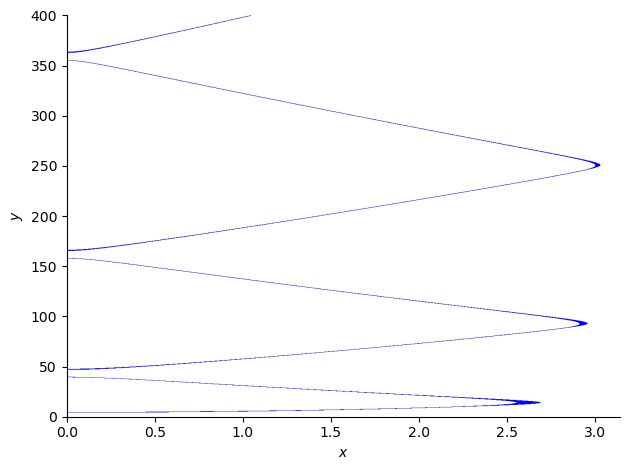

In [4]:
from sympy import symbols, plot_implicit
from sympy.parsing.sympy_parser import parse_expr
import numpy as np
d1=2
d2=2
x, y = symbols('x y')
expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) + ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
expr = parse_expr(expr_str)
plot = plot_implicit(expr, (x, 0, np.pi), (y, 0, 400), show=False)
plot.show()

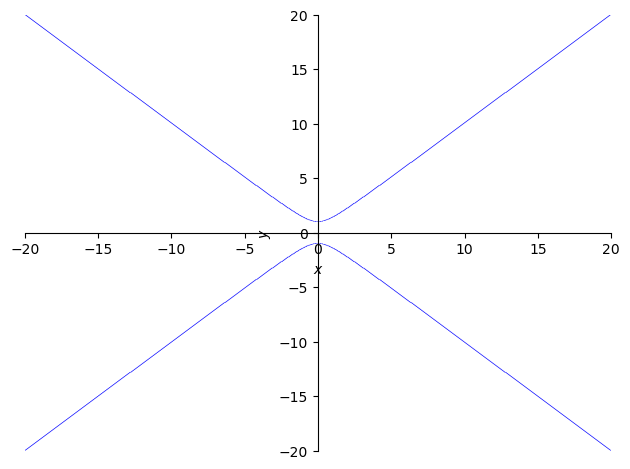

In [1]:
from sympy import symbols, plot_implicit
from sympy.parsing.sympy_parser import parse_expr
d1=1
d2=0.1
x, y = symbols('x y')
expr_str = f'y**2-x**2-1'
expr = parse_expr(expr_str)
plot = plot_implicit(expr, (x, -20, 20), (y, -20, 20), show=False)
plot.show()

-------------------y1=0.1,y2=0.1-------------------------


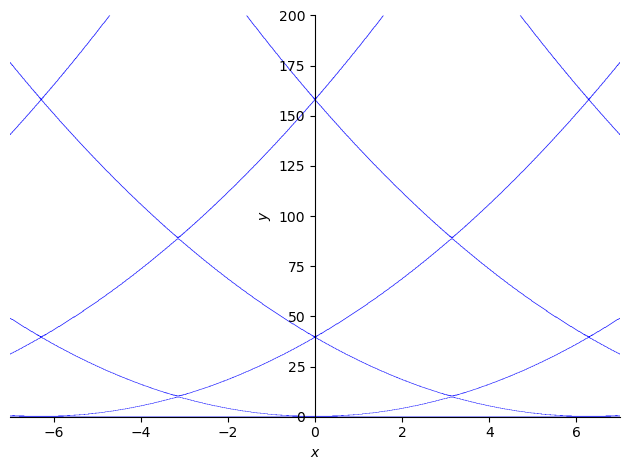

-------------------y1=0.1,y2=0.2-------------------------


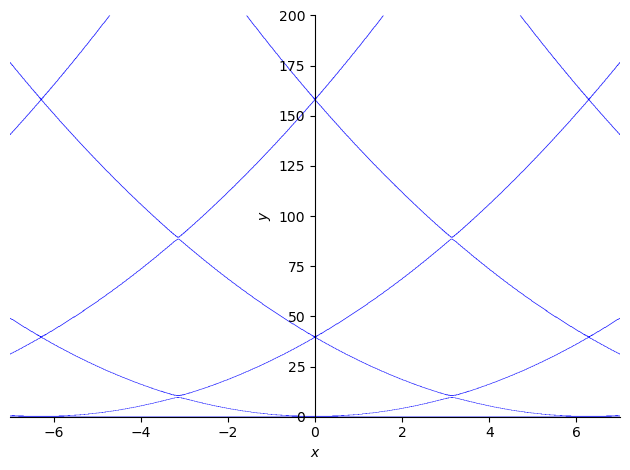

-------------------y1=0.1,y2=0.3-------------------------


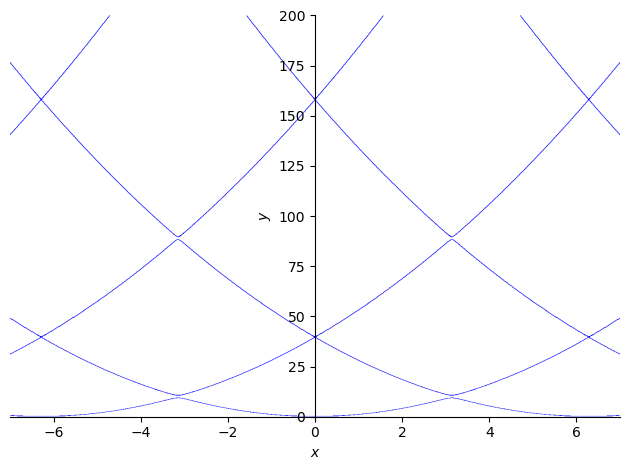

-------------------y1=0.2,y2=0.1-------------------------


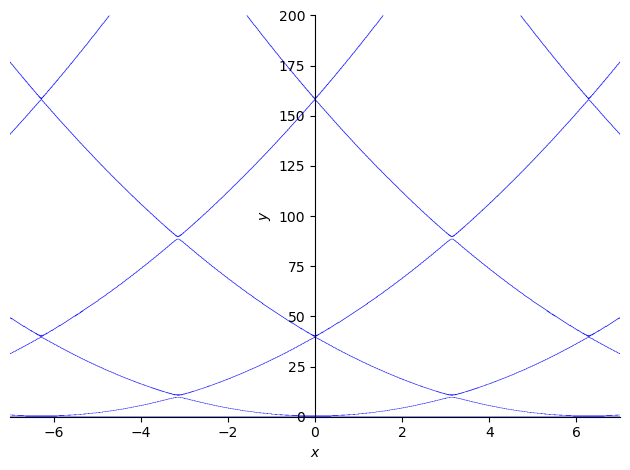

-------------------y1=0.2,y2=0.2-------------------------


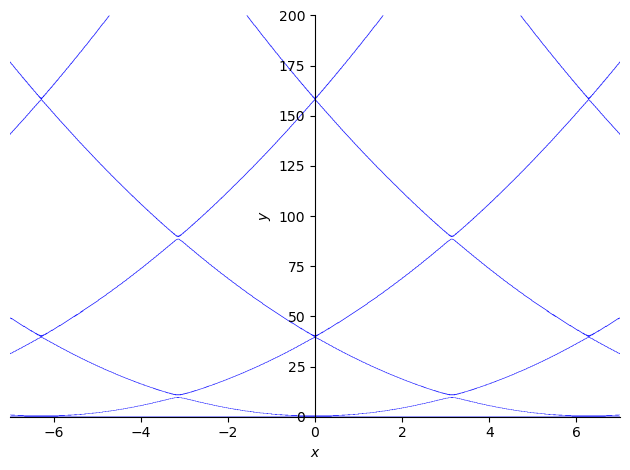

-------------------y1=0.2,y2=0.3-------------------------


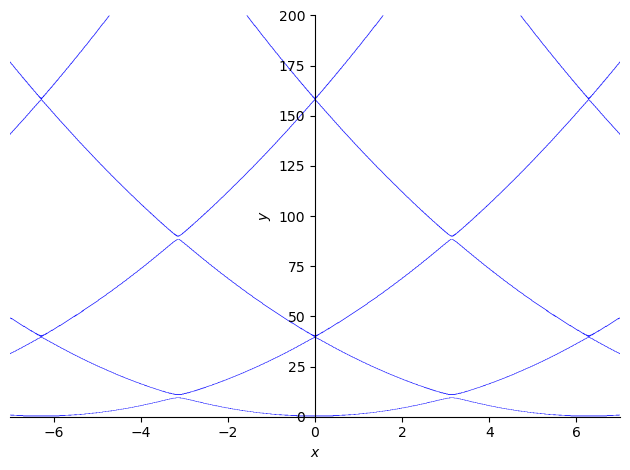

-------------------y1=0.3,y2=0.1-------------------------


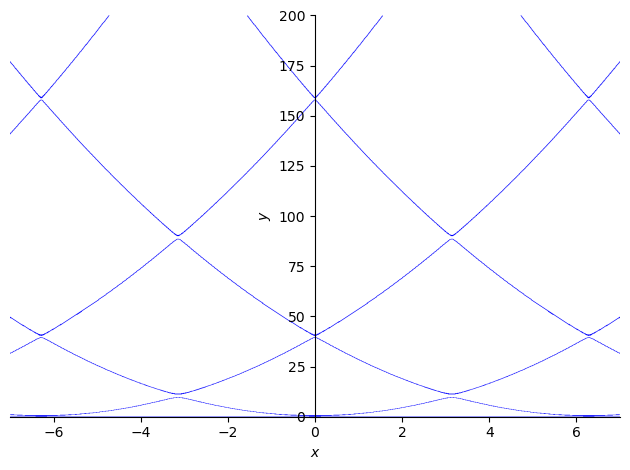

-------------------y1=0.3,y2=0.2-------------------------


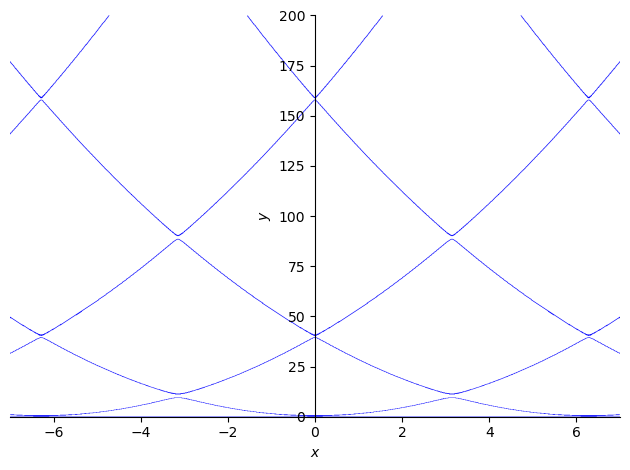

-------------------y1=0.3,y2=0.3-------------------------


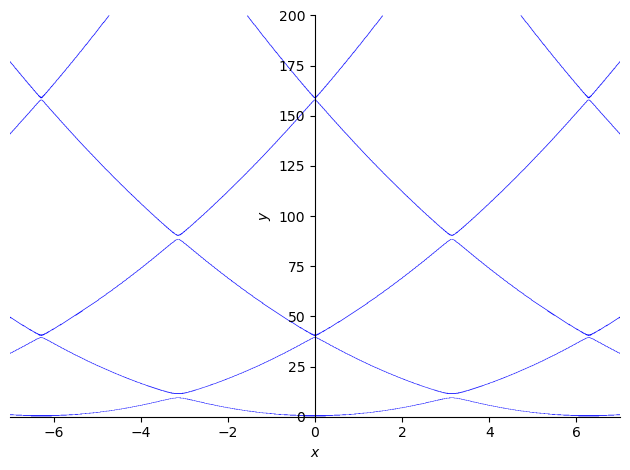

In [98]:
from sympy import symbols, plot_implicit
from sympy.parsing.sympy_parser import parse_expr
d11=[0.1,0.2,0.3]
d22=[0.1,0.2,0.3]
for d1 in d11:
    for d2 in d22:
        print(f'-------------------y1={d1},y2={d2}-------------------------')
        x, y = symbols('x y')
        expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) - ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
        expr = parse_expr(expr_str)
        plot = plot_implicit(expr, (x, -4, 4), (y, 0, 200), show=False)
        plot.show()

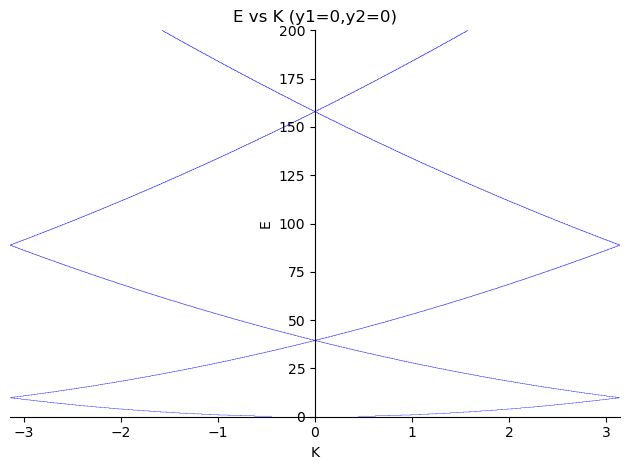

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, plot_implicit

# 定义符号变量
x, y = symbols('x y')

# 定义 d1 和 d2 的值
d1, d2 = 0, 0

# 定义隐函数表达式
expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) - ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
expr = parse_expr(expr_str)

# 绘制隐函数图
p = plot_implicit(expr, (x, -np.pi, np.pi), (y, 0, 200), adaptive=True, 
                  xlabel='K', ylabel='E', title=f'E vs K (y1={d1},y2={d2})', show=False)

# 显示图形
p.show()

-------------------y1=0, y2=0-------------------------
-------------------y1=0, y2=2-------------------------
-------------------y1=0, y2=4-------------------------
-------------------y1=0, y2=8-------------------------


<lambdifygenerated-70909>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-70910>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-70911>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(64*cos(sqrt(y)) - 64)/y
<lambdifygenerated-70912>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)


-------------------y1=2, y2=0-------------------------
-------------------y1=2, y2=2-------------------------
-------------------y1=2, y2=4-------------------------
-------------------y1=2, y2=8-------------------------


<lambdifygenerated-70913>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70914>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70915>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(68*cos(sqrt(y)) - 68)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70916>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70917>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 4*sin(sqrt(y))/sqrt(y)


-------------------y1=4, y2=0-------------------------
-------------------y1=4, y2=2-------------------------
-------------------y1=4, y2=4-------------------------
-------------------y1=4, y2=8-------------------------


<lambdifygenerated-70918>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(32*cos(sqrt(y)) - 32)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70919>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(80*cos(sqrt(y)) - 80)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70920>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(64*cos(sqrt(y)) - 64)/y - 8*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70921>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(68*cos(sqrt(y)) - 68)/y - 8*sin(sqrt(y))/sqrt(y)


-------------------y1=8, y2=0-------------------------
-------------------y1=8, y2=2-------------------------
-------------------y1=8, y2=4-------------------------
-------------------y1=8, y2=8-------------------------


<lambdifygenerated-70922>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(80*cos(sqrt(y)) - 80)/y - 8*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70923>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(128*cos(sqrt(y)) - 128)/y - 8*sin(sqrt(y))/sqrt(y)


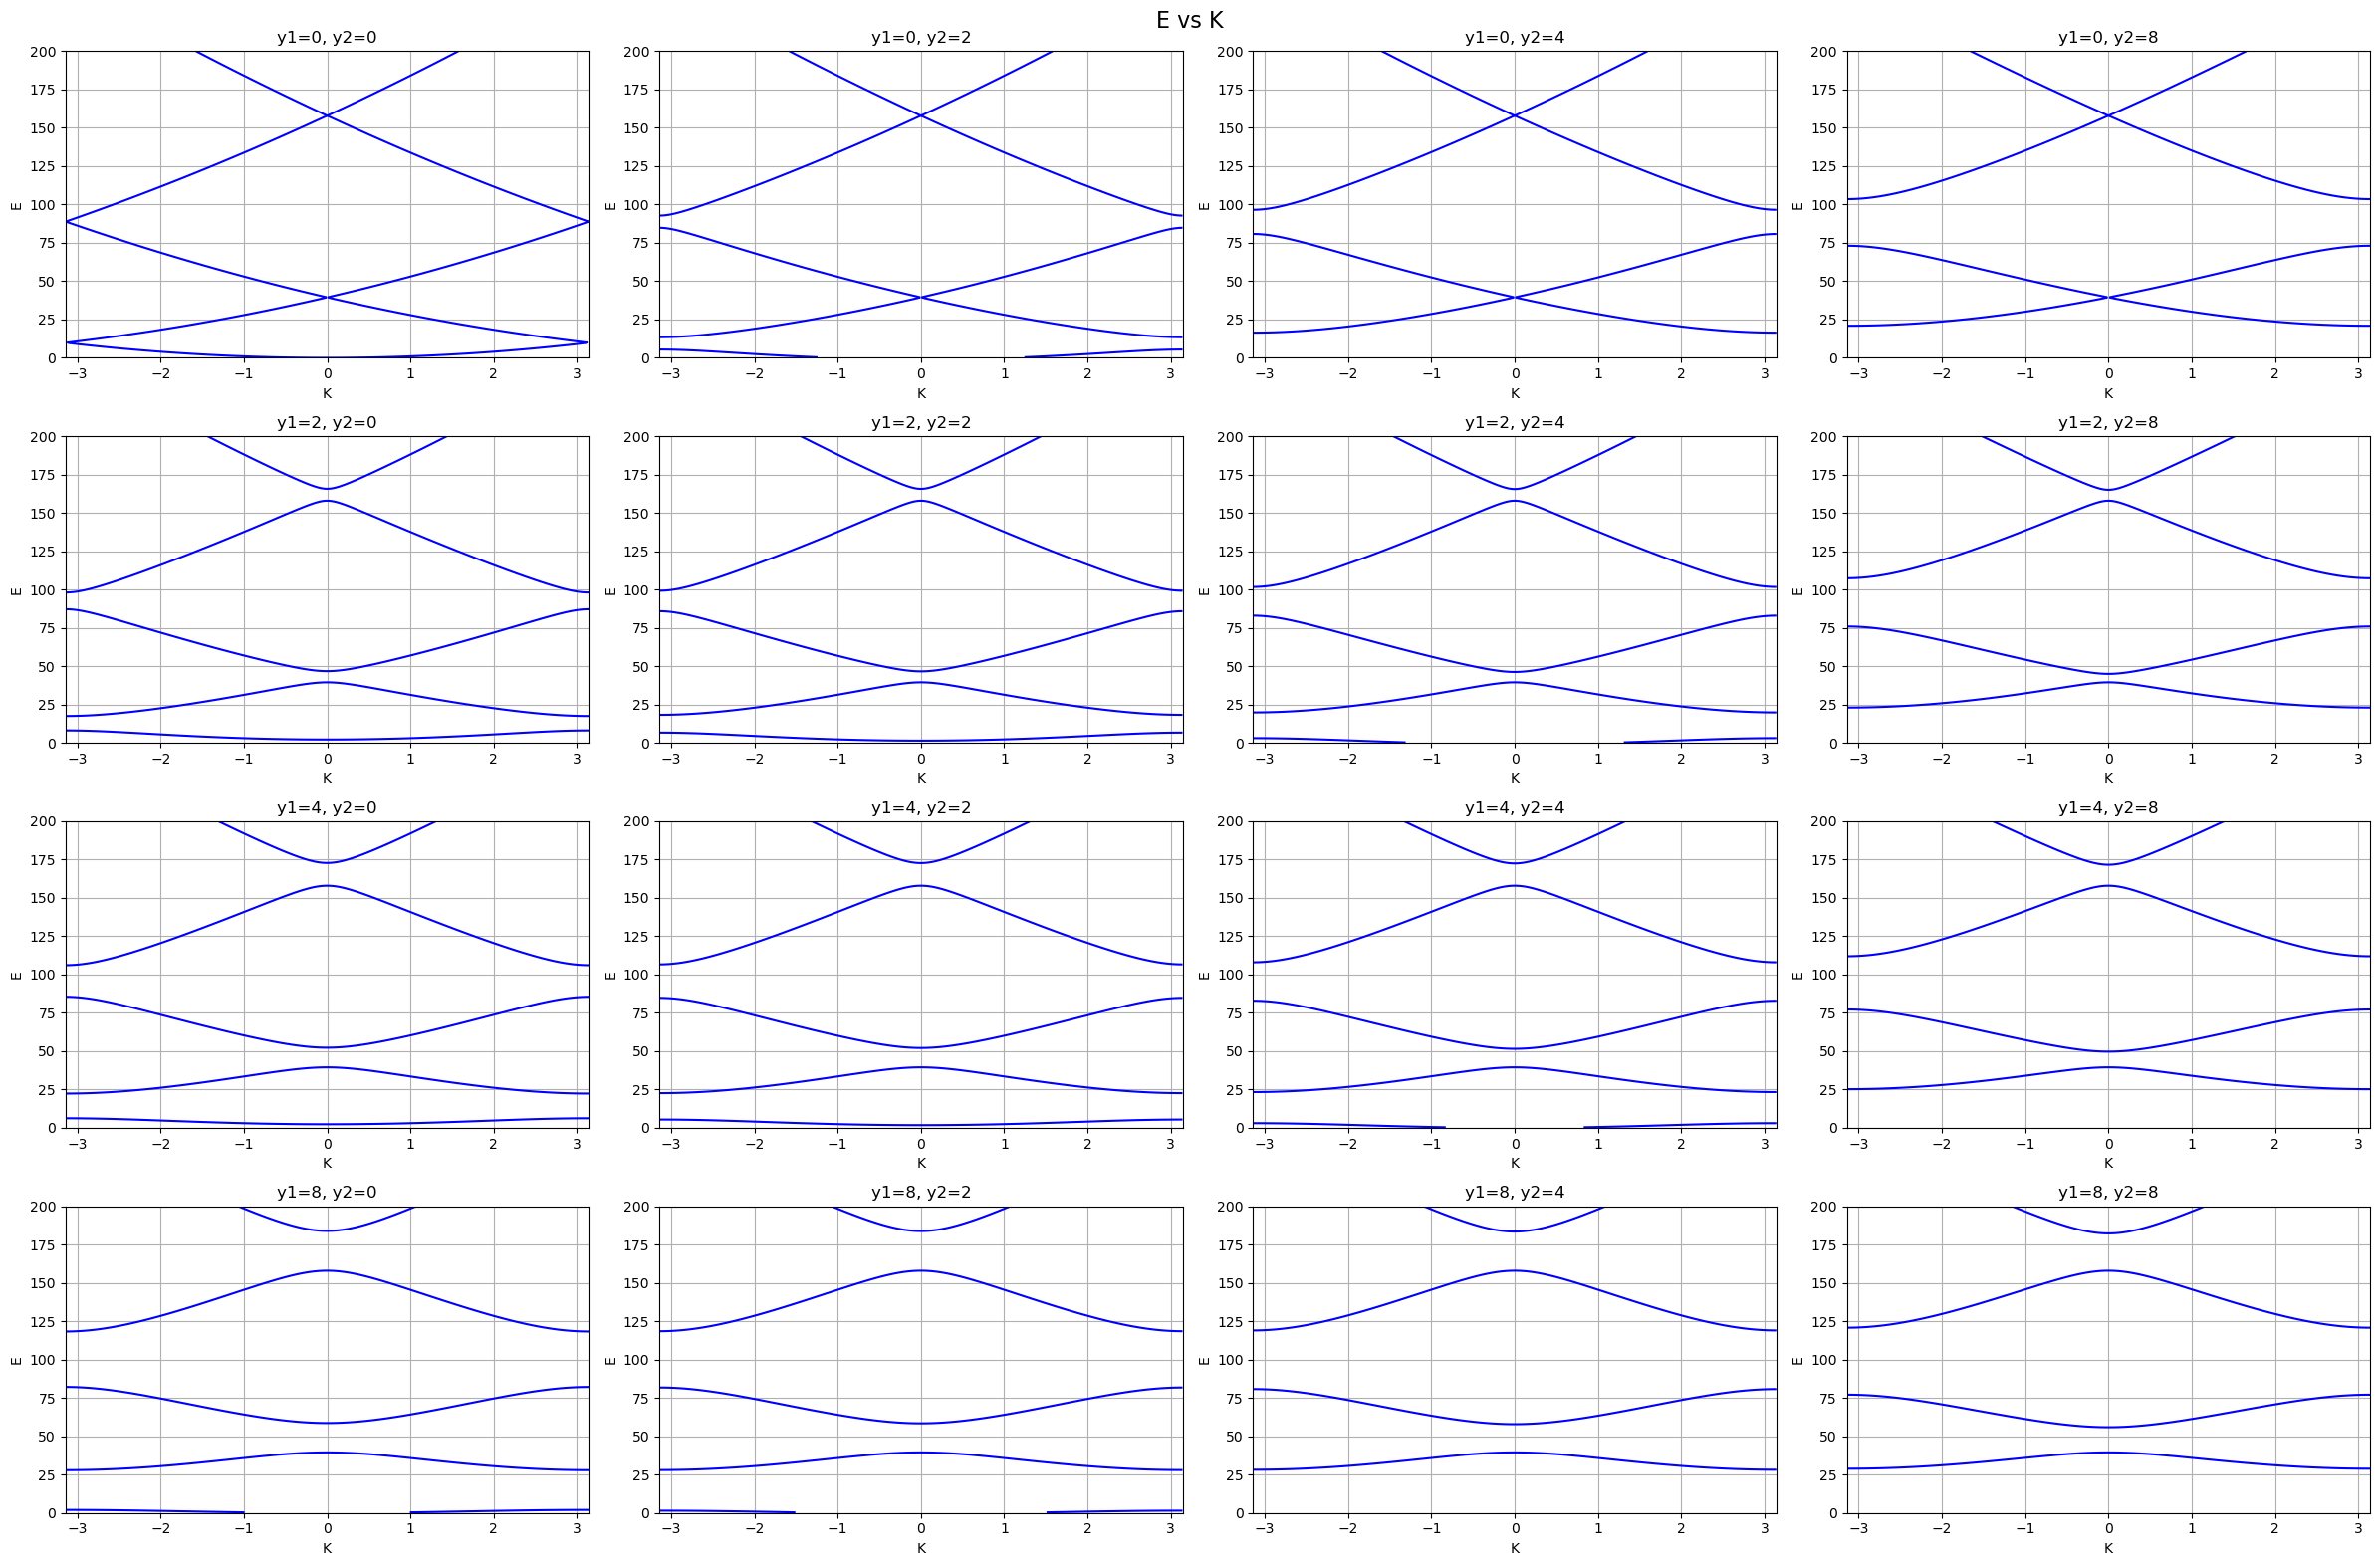

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0, 2, 4, 8]
d22 = [0, 2, 4, 8]

# 创建动态子图布局
num_rows = len(d11)
num_cols = len(d22)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows))  # 动态调整子图大小
fig.suptitle('E vs K', fontsize=16)  # 总标题

# 定义符号变量
x, y = symbols('x y')

# 遍历 d1 和 d2 的值
for i, d1 in enumerate(d11):
    for j, d2 in enumerate(d22):
 #       print(f'-------------------y1={d1}, y2={d2}-------------------------')
        
        # 定义隐函数表达式
        expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) - ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
        expr = parse_expr(expr_str)
        
        # 将 SymPy 表达式转换为 NumPy 可计算的函数
        func = lambdify((x, y), expr, modules='numpy')
        
        # 创建网格数据
        x_vals = np.linspace(-np.pi, np.pi, 500)
        y_vals = np.linspace(0, 200, 500)
        X, Y = np.meshgrid(x_vals, y_vals)
        Z = func(X, Y)
        
        # 绘制隐函数图
        axes[i, j].contour(X, Y, Z, levels=[0], colors='blue')  # 绘制隐函数的零等高线
        axes[i, j].set_xlabel('K')
        axes[i, j].set_ylabel('E')
        axes[i, j].set_title(f'y1={d1}, y2={d2}')
        axes[i, j].grid(True)
        axes[i, j].set_xlim(-np.pi, np.pi)  # x 轴范围
        axes[i, j].set_ylim(0, 200)  # y 轴范围

plt.tight_layout()  # 调整子图布局
plt.show()

In [1]:
import os                         

# 指定路径
path = r"C:\Users\taoji\Desktop\结果\E vs K"

# 创建文件夹
try:
    os.makedirs(path)
    print(f"文件夹 '{path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")



文件夹 'C:\Users\taoji\Desktop\结果\E vs K' 创建成功


In [144]:
# 切换到交互式后端（例如 qt）
%matplotlib qt

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0, 2, 4]
d22 = [0, 2, 4]

# 创建动态子图布局
num_rows = len(d11)
num_cols = len(d22)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))  # 动态调整子图大小
fig.suptitle('E vs K', fontsize=16)  # 总标题

# 定义符号变量
x, y = symbols('x y')

# 遍历 d1 和 d2 的值
for i, d1 in enumerate(d11):
    for j, d2 in enumerate(d22):
        # 定义隐函数表达式
        expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) - ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
        expr = parse_expr(expr_str)
        
        # 将 SymPy 表达式转换为 NumPy 可计算的函数
        func = lambdify((x, y), expr, modules='numpy')
        
        # 创建网格数据
        x_vals = np.linspace(-np.pi, np.pi, 2000)
        y_vals = np.linspace(0, 1600, 2000)
        X, Y = np.meshgrid(x_vals, y_vals)
        Z = func(X, Y)
        
        # 绘制隐函数图
        axes[i, j].contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)  # 绘制隐函数的零等高线
        axes[i, j].set_xlabel('K')
        axes[i, j].set_ylabel('E')
        axes[i, j].set_title(f'y1={d1}, y2={d2}')
        axes[i, j].grid(True)
        axes[i, j].set_xlim(-np.pi, np.pi)  # x 轴范围
        axes[i, j].set_ylim(0, 50)  # y 轴范围

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

<lambdifygenerated-71103>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-71104>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-71105>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-71106>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-71107>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-71108>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-71109>:2: RuntimeWarning: inv

In [2]:
import os                                               ######### E vs K
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, parse_expr, lambdify

# 定义 d1 和 d2 的值
d11 = [0, 2, 4]
d22 = [0, 2, 4]

# 定义 E 的范围
E = [(0, 1600), (0, 50), (0, 400), (400, 800), (800, 1200), (1200, 1600)]

# 定义 x 的范围
x_vals = np.linspace(-np.pi, np.pi, 2000)

# 动态生成文件夹名称
#mingming = f'E VS K{{real = {d11}, imag = {d22}}}'
mingming = f'E VS K'
folder_path = os.path.join(r"C:\Users\taoji\Desktop\结果", mingming)

# 创建文件夹
try:
    os.makedirs(folder_path)
    print(f"文件夹 '{folder_path}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{folder_path}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 定义符号变量
x, y = symbols('x y')

# 遍历 E 的范围
for e_min, e_max in E:
    # 创建动态子图布局
    num_rows = len(d11)
    num_cols = len(d22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 8 * num_rows))
    fig.suptitle(f'E vs K (E={e_min}-{e_max})', fontsize=16)

    # 遍历 d1 和 d2 的值
    for i, d1 in enumerate(d11):
        for j, d2 in enumerate(d22):
            # 定义隐函数表达式
            expr_str = f'cos(x) - cos(sqrt(y)) - 2*{d1}*sin(sqrt(y))/(2*sqrt(y)) - ({d1}**2+{d2}**2)*(cos(sqrt(y)) - 1)/(4*y)'
            expr = parse_expr(expr_str)

            # 将 SymPy 表达式转换为 NumPy 可计算的函数
            func = lambdify((x, y), expr, modules='numpy')

            # 创建网格数据
            y_vals = np.linspace(e_min, e_max, 2000)
            X, Y = np.meshgrid(x_vals, y_vals)
            Z = func(X, Y)

            # 绘制隐函数图
            axes[i, j].contour(X, Y, Z, levels=[0], colors='blue', linewidths=0.8)
            axes[i, j].set_xlabel('K')
            axes[i, j].set_ylabel('E')
            axes[i, j].set_title(f'y1={d1}, y2={d2}')
            axes[i, j].grid(True)
            axes[i, j].set_xlim(-np.pi, np.pi)
            axes[i, j].set_ylim(e_min, e_max)

    # 调整子图布局
    plt.tight_layout()

    # 保存图像到文件夹
    file_name = f'E vs K({e_min}，{e_max}).png'  # 修改文件名格式
   # file_name = f'E vs K.png'  # 修改文件名格式
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path)
    plt.close()  # 关闭当前图形，避免内存泄漏
    print(f"图像已保存到: {file_path}")

print("所有图像生成完成！")

文件夹 'C:\Users\taoji\Desktop\结果\E VS K' 已经存在


<lambdifygenerated-56>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-57>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-58>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-59>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-60>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-61>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-62>:2: RuntimeWarning: invalid value encountere

图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(0，1600).png


<lambdifygenerated-65>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-66>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-67>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-68>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-69>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-70>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-71>:2: RuntimeWarning: invalid value encountere

图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(0，50).png


<lambdifygenerated-74>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y
<lambdifygenerated-75>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y
<lambdifygenerated-76>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(4*cos(sqrt(y)) - 4)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-77>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(8*cos(sqrt(y)) - 8)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-78>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(20*cos(sqrt(y)) - 20)/y - 2*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-79>:2: RuntimeWarning: invalid value encountered in divide
  return cos(x) - cos(sqrt(y)) - 1/4*(16*cos(sqrt(y)) - 16)/y - 4*sin(sqrt(y))/sqrt(y)
<lambdifygenerated-80>:2: RuntimeWarning: invalid value encountere

图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(0，400).png
图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(400，800).png
图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(800，1200).png
图像已保存到: C:\Users\taoji\Desktop\结果\E VS K\E vs K(1200，1600).png
所有图像生成完成！


In [71]:
from sympy import symbols, nsolve, cos, sin, sqrt
import numpy as np
# 定义一个函数，给定 x 值，列出在 0 到 200 范围内的 y 值
def find_y_values_for_x(expr, x_val, y_range=(0, 200), step=1):
    y_values = []
    for y_guess in np.arange(y_range[0] + step, y_range[1], step):
        try:
            # 使用 nsolve 求解 y 值
            y_val = nsolve(expr.subs(x, x_val), y_guess)
            if y_range[0] <= y_val <= y_range[1]:  # 确保 y 值在范围内
                y_values.append(y_val)
        except:
            continue  # 如果求解失败，跳过
    return y_values
d1 = 1
d2 = 0.1
x, y = symbols('x y')
expr = cos(x) - cos(sqrt(y)) - 2 * d1 * sin(sqrt(y)) / (2 * sqrt(y)) - (d1**2 + d2**2) * (cos(sqrt(y)) - 1) / (4 * y)

x_val_1=[0,np.pi]
y_val_1=[0]*len(x_val_1)
y_val_3=[]
for i,j in zip(np.arange(len(x_val_1)),x_val_1):
    y_values_2 = find_y_values_for_x(expr, j)
    y_values_2=list(set(y_values_2))
    y_values_2.sort()
    y_val_1[i]=y_values_2
    y_val_3+=y_val_1[i]
y_val_3.sort()
print(y_val_3)

[1.49235871913593, 9.01616562573673, 14.1619263892568, 39.4784176043574, 43.3355440887941, 87.9891056144762, 93.5751644638869, 157.913670417430, 161.874739611298]


y_val_3: [3.68785069435896, 13.4923306208491, 13.4923471167631, 13.4923472911490, 13.4923484543594, 13.4923495440337, 13.4923505631077, 13.4923515144172, 13.4923521541450, 13.4923524006991, 13.4923532245934, 13.4923534774222, 13.4923539107531, 13.4923539886471, 13.4923546953213, 13.4923553470153, 13.4923559461508, 13.4923562958982, 13.4923564956350, 13.4923570063720, 13.4923574298835, 13.4923577397674, 13.4923578431841, 13.4923582073756, 13.4923585282758, 13.4923585539318, 13.4923588075916, 13.4923590398255, 13.4923590463215, 13.4923592449804, 13.4923593354666, 13.4923594035260, 13.4923595097599, 13.4923595211522, 13.4923595959242, 13.4923595992500, 13.4923596241470, 13.4923646612953, 39.4784176043574, 47.0874366550028, 92.7692728226904, 92.7692799506947, 92.7693109529353, 92.7693239752415, 92.7693250241817, 92.7693311460863, 92.7693367060835, 92.7693377464087, 92.7693377549072, 92.7693378000343, 92.7693378366518, 92.7693379070994, 92.7693380062289, 92.7693380606662, 92.7693382550712, 

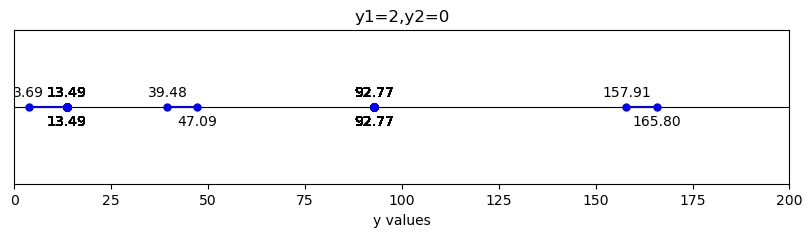

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, nsolve, cos, sin, sqrt

# 定义一个函数，给定 x 值，列出在 0 到 200 范围内的 y 值
def find_y_values_for_x(expr, x_val, y_range=(0, 200), step=1):
    y_values = []
    for y_guess in np.arange(y_range[0] + step, y_range[1], step):
        try:
            # 使用 nsolve 求解 y 值
            y_val = nsolve(expr.subs(x, x_val), y_guess)
            if y_range[0] <= y_val <= y_range[1]:  # 确保 y 值在范围内
                y_values.append(y_val)
        except:
            continue  # 如果求解失败，跳过
    return y_values
    
# 绘制水平轴并标注 y 值
def plot_y_values(y_val_3):
    fig, ax = plt.subplots(figsize=(10, 2))  # 创建一个水平轴
    ax.set_xlim(0, 200)  # 设置 x 轴范围
    ax.set_ylim(-1, 1)  # 设置 y 轴范围（仅用于显示水平线）
    ax.axhline(0, color='black', linewidth=0.8)  # 绘制水平线

    # 如果 y_val_3 的值数是奇数，去掉最大的一个
    if len(y_val_3) % 2 != 0:
        y_val_3 = y_val_3[:-1]

    # 每两个点连接一次
    for i in range(0, len(y_val_3), 2):
        y1 = y_val_3[i]
        y2 = y_val_3[i + 1]
        ax.plot([y1, y2], [0, 0], marker='o', markersize=5, color='blue')  # 连接点并标注
        ax.text(y1, 0.1, f'{y1:.2f}', ha='center', va='bottom')  # 标注 y1 值（在轴上方）
        ax.text(y2, -0.1, f'{y2:.2f}', ha='center', va='top')  # 标注 y2 值（在轴下方）

    ax.set_yticks([])  # 隐藏 y 轴刻度
    ax.set_xlabel('y values')  # 设置 x 轴标签
    plt.title(f'y1={d1},y2={d2}')  # 设置标题
    plt.show()
d11=[2]
d22=[0]
for d1 in d11:
    for d2 in d22:
        # 定义符号变量
        x, y = symbols('x y')
        # 定义隐函数方程
        expr = cos(x) - cos(sqrt(y)) - 2 * d1 * sin(sqrt(y)) / (2 * sqrt(y)) + (d1**2 + d2**2) * (cos(sqrt(y)) - 1) / (4 * y)
        
        
        
        # 给定的 x 值
        x_val_1 = [0, np.pi]
        y_val_1 = [0] * len(x_val_1)
        y_val_3 = []
        
        # 计算每个 x 值对应的 y 值
        for i, j in zip(np.arange(len(x_val_1)), x_val_1):
            y_values_2 = find_y_values_for_x(expr, j)
            y_values_2 = list(set(y_values_2))  # 去重
            y_values_2.sort()  # 排序
            y_val_1[i] = y_values_2
            y_val_3 += y_val_1[i]  # 将 y 值合并到 y_val_3
        
        y_val_3.sort()  # 对 y_val_3 进行排序
        print("y_val_3:", y_val_3)
        
        # 调用绘图函数
        plot_y_values(y_val_3)

d1=2, d2=0, y_val_3: [3.68785069435896, 39.4784176043574, 47.0874366550028, 157.913670417430, 165.801530197717, 355.305758439217, 363.254463905502]


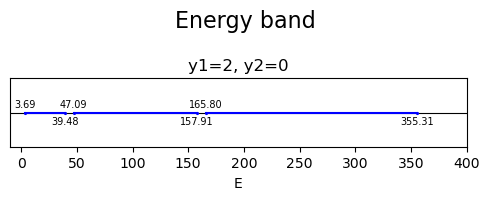

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, nsolve, cos, sin, sqrt

# 定义一个函数，给定 x 值，列出在 0 到 200 范围内的 y 值
def find_y_values_for_x(expr, x_val, y_range=(0, 400), step=1):
    y_values = []
    for y_guess in np.arange(y_range[0] + step, y_range[1], step):
        try:
            # 使用 nsolve 求解 y 值
            y_val = nsolve(expr.subs(x, x_val), y_guess)
            if y_range[0] <= y_val <= y_range[1]:  # 确保 y 值在范围内
                y_values.append(y_val)
        except:
            continue  # 如果求解失败，跳过
    return y_values

# 绘制水平轴并标注 y 值
def plot_y_values(y_val_3, ax, d1, d2):
    ax.set_xlim(-10, 400)  # 设置 x 轴范围
    ax.set_ylim(-1, 1)  # 设置 y 轴范围（仅用于显示水平线）
    ax.axhline(0, color='black', linewidth=0.8)  # 绘制水平线

    # 如果 y_val_3 的值数是奇数，去掉最大的一个
    if len(y_val_3) % 2 != 0:
        y_val_3 = y_val_3[:-1]

    # 每两个点连接一次
    for i in range(0, len(y_val_3), 2):
        y1 = y_val_3[i]
        y2 = y_val_3[i + 1]
        ax.plot([y1, y2], [0, 0], marker='o', markersize=1.25, color='blue')  # 连接点并标注
        ax.text(y1, 0.1, f'{y1:.2f}', ha='center', va='bottom', fontsize=7)  # 标注 y1 值（在轴上方），字体调小
        ax.text(y2, -0.1, f'{y2:.2f}', ha='center', va='top', fontsize=7)  # 标注 y2 值（在轴下方），字体调小

    ax.set_yticks([])  # 隐藏 y 轴刻度
    ax.set_xlabel('E', fontsize=10)  # 设置 x 轴标签
    ax.set_title(f'y1={d1}, y2={d2}', fontsize=12)  # 设置标题

# 定义 d1 和 d2 的值
d11 = [2]
d22 = [0]

# 创建动态子图布局
num_rows = len(d11)
num_cols = len(d22)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 2 * num_rows))  # 动态调整子图大小
fig.suptitle('Energy band', fontsize=16)  # 总标题

# 遍历 d1 和 d2 的值
for i, d1 in enumerate(d11):
    for j, d2 in enumerate(d22):
        # 定义符号变量
        x, y = symbols('x y')
        # 定义隐函数方程
        expr = cos(x) - cos(sqrt(y)) - 2 * d1 * sin(sqrt(y)) / (2 * sqrt(y)) + (d1**2 + d2**2) * (cos(sqrt(y)) - 1) / (4 * y)

        # 给定的 x 值
        x_val_1 = [0]
        y_val_1 = [0] * len(x_val_1)
        y_val_3 = []

        # 计算每个 x 值对应的 y 值
        for k, val in zip(np.arange(len(x_val_1)), x_val_1):
            y_values_2 = find_y_values_for_x(expr, val)
            y_values_2 = list(set(y_values_2))  # 去重
            y_values_2.sort()  # 排序
            y_val_1[k] = y_values_2
            y_val_3 += y_val_1[k]  # 将 y 值合并到 y_val_3

        y_val_3.sort()  # 对 y_val_3 进行排序
        print(f"d1={d1}, d2={d2}, y_val_3:", y_val_3)

        # 在当前子图中绘制 y 值
        if num_rows == 1 and num_cols == 1:
            plot_y_values(y_val_3, axes, d1, d2)  # 如果只有一个子图，直接使用 axes
        elif num_rows == 1 or num_cols == 1:
            plot_y_values(y_val_3, axes[i + j], d1, d2)  # 如果只有一行或一列，使用 axes[i + j]
        else:
            plot_y_values(y_val_3, axes[i, j], d1, d2)  # 否则使用 axes[i, j]

plt.tight_layout()  # 调整子图布局
plt.show()

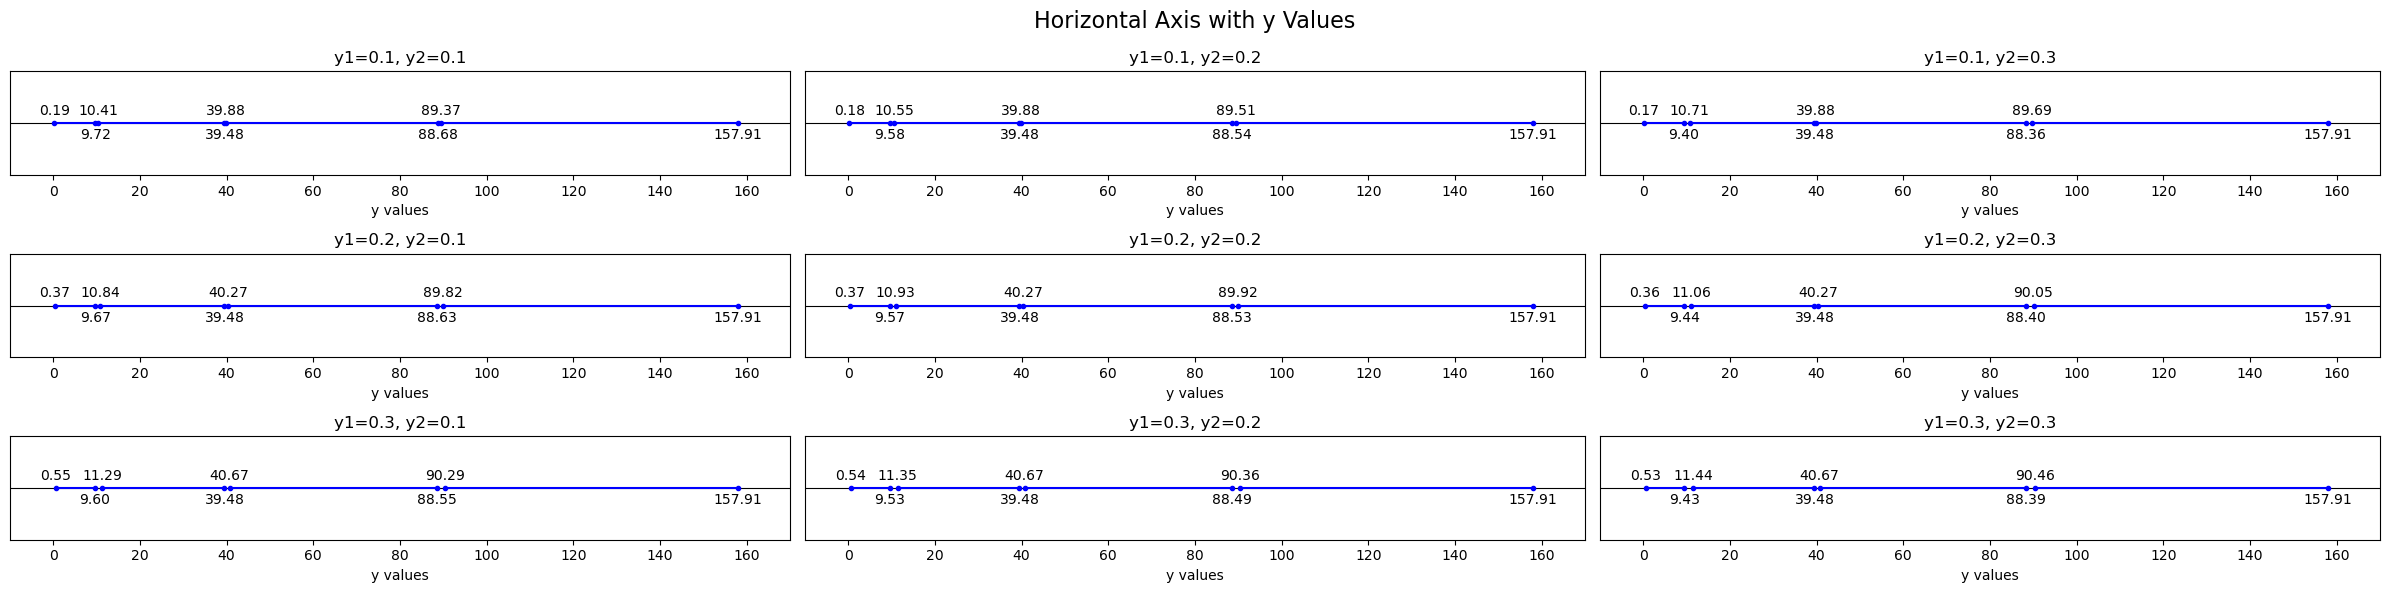

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, nsolve, cos, sin, sqrt

# 定义一个函数，给定 x 值，列出在 0 到 200 范围内的 y 值
def find_y_values_for_x(expr, x_val, y_range=(0, 200), step=1):
    y_values = []
    for y_guess in np.arange(y_range[0] + step, y_range[1], step):
        try:
            # 使用 nsolve 求解 y 值
            y_val = nsolve(expr.subs(x, x_val), y_guess)
            if y_range[0] <= y_val <= y_range[1]:  # 确保 y 值在范围内
                y_values.append(y_val)
        except:
            continue  # 如果求解失败，跳过
    return y_values

# 绘制水平轴并标注 y 值
def plot_y_values(y_val_3, ax, d1, d2):
    ax.set_xlim(-10, 170)  # 设置 x 轴范围
    ax.set_ylim(-1, 1)  # 设置 y 轴范围（仅用于显示水平线）
    ax.axhline(0, color='black', linewidth=0.8)  # 绘制水平线

    # 如果 y_val_3 的值数是奇数，去掉最大的一个
    if len(y_val_3) % 2 != 0:
        y_val_3 = y_val_3[:-1]

    # 每两个点连接一次
    for i in range(0, len(y_val_3), 2):
        y1 = y_val_3[i]
        y2 = y_val_3[i + 1]
        ax.plot([y1, y2], [0, 0], marker='o', markersize=3, color='blue')  # 连接点并标注，markersize 缩小 4 倍
        ax.text(y1, 0.1, f'{y1:.2f}', ha='center', va='bottom', fontsize=10)  # 标注 y1 值（在轴上方），字体调小
        ax.text(y2, -0.1, f'{y2:.2f}', ha='center', va='top', fontsize=10)  # 标注 y2 值（在轴下方），字体调小

    ax.set_yticks([])  # 隐藏 y 轴刻度
    ax.set_xlabel('y values', fontsize=10)  # 设置 x 轴标签
    ax.set_title(f'y1={d1}, y2={d2}', fontsize=12)  # 设置标题

# 定义 d1 和 d2 的值
d11 = [0.1, 0.2, 0.3]
d22 = [0.1, 0.2, 0.3]

# 创建动态子图布局
num_rows = len(d11)
num_cols = len(d22)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8 * num_cols, 2* num_rows))  # 动态调整子图大小
fig.suptitle('Horizontal Axis with y Values', fontsize=16)  # 总标题

# 遍历 d1 和 d2 的值
for i, d1 in enumerate(d11):
    for j, d2 in enumerate(d22):
        # 定义符号变量
        x, y = symbols('x y')
        # 定义隐函数方程
        expr = cos(x) - cos(sqrt(y)) - 2 * d1 * sin(sqrt(y)) / (2 * sqrt(y)) - (d1**2 + d2**2) * (cos(sqrt(y)) - 1) / (4 * y)

        # 给定的 x 值
        x_val_1 = [0, np.pi]
        y_val_1 = [0] * len(x_val_1)
        y_val_3 = []

        # 计算每个 x 值对应的 y 值
        for k, val in zip(np.arange(len(x_val_1)), x_val_1):
            y_values_2 = find_y_values_for_x(expr, val)
            y_values_2 = list(set(y_values_2))  # 去重
            y_values_2.sort()  # 排序
            y_val_1[k] = y_values_2
            y_val_3 += y_val_1[k]  # 将 y 值合并到 y_val_3

        y_val_3.sort()  # 对 y_val_3 进行排序
 #       print(f"d1={d1}, d2={d2}, y_val_3:", y_val_3)

        # 在当前子图中绘制 y 值
        if num_rows == 1 and num_cols == 1:
            plot_y_values(y_val_3, axes, d1, d2)  # 如果只有一个子图，直接使用 axes
        elif num_rows == 1 or num_cols == 1:
            plot_y_values(y_val_3, axes[i + j], d1, d2)  # 如果只有一行或一列，使用 axes[i + j]
        else:
            plot_y_values(y_val_3, axes[i, j], d1, d2)  # 否则使用 axes[i, j]

plt.tight_layout()  # 调整子图布局
plt.show()